# Plotting


In [1]:
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.ticker as tkr
from matplotlib.offsetbox import AnchoredText
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

#Plot params
# -- Axes --
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.axisbelow'] = False
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['axes.ymargin'] = 0.1
plt.rcParams["font.size"] = 10
plt.rcParams["figure.dpi"] = 600
# -- Ticks and tick labels --
plt.rcParams['axes.edgecolor'] = 'k'
plt.rcParams['xtick.color'] = 'k'
plt.rcParams['ytick.color'] = 'k'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 0.5
plt.rcParams['ytick.major.size'] = 0.5
# -- Fonts --
plt.rcParams['font.size'] = 8
plt.rcParams['text.color'] = 'k'
plt.rcParams['axes.labelcolor'] = 'k'
plt.rcParams['axes.labelsize'] = 8
# -- Saving Options --
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.transparent'] = False
# -- Plot Styles --
plt.rcParams['lines.linewidth'] = 1
plt.rcParams["lines.markersize"] = 0.1
plt.rcParams["lines.markeredgewidth"] = 0.1
plt.rcParams["figure.dpi"] = 600

mm = 1/25.4


In [2]:
def nansmad(x):
    return 1.4826 * np.nanmedian(np.abs(x - np.nanmedian(x)))

# Read results

In [3]:
catalog = pd.read_csv("../CSN_bulletin_close.csv", parse_dates=["time"])
sel_event = "20260222T142257"
event_info = catalog.loc[catalog["event_id"] == sel_event].iloc[0]

phase = "P"
wlen = 6

magnitude_df = pd.read_csv(f"../results/magnitude_estimation_{sel_event}_{phase}_wlen{wlen}.csv")
true_mag = event_info["mag"]
median_mag = np.nanmedian(magnitude_df["magnitude"].values)
eror_mag = nansmad(magnitude_df["magnitude"].values)

# Magnitude


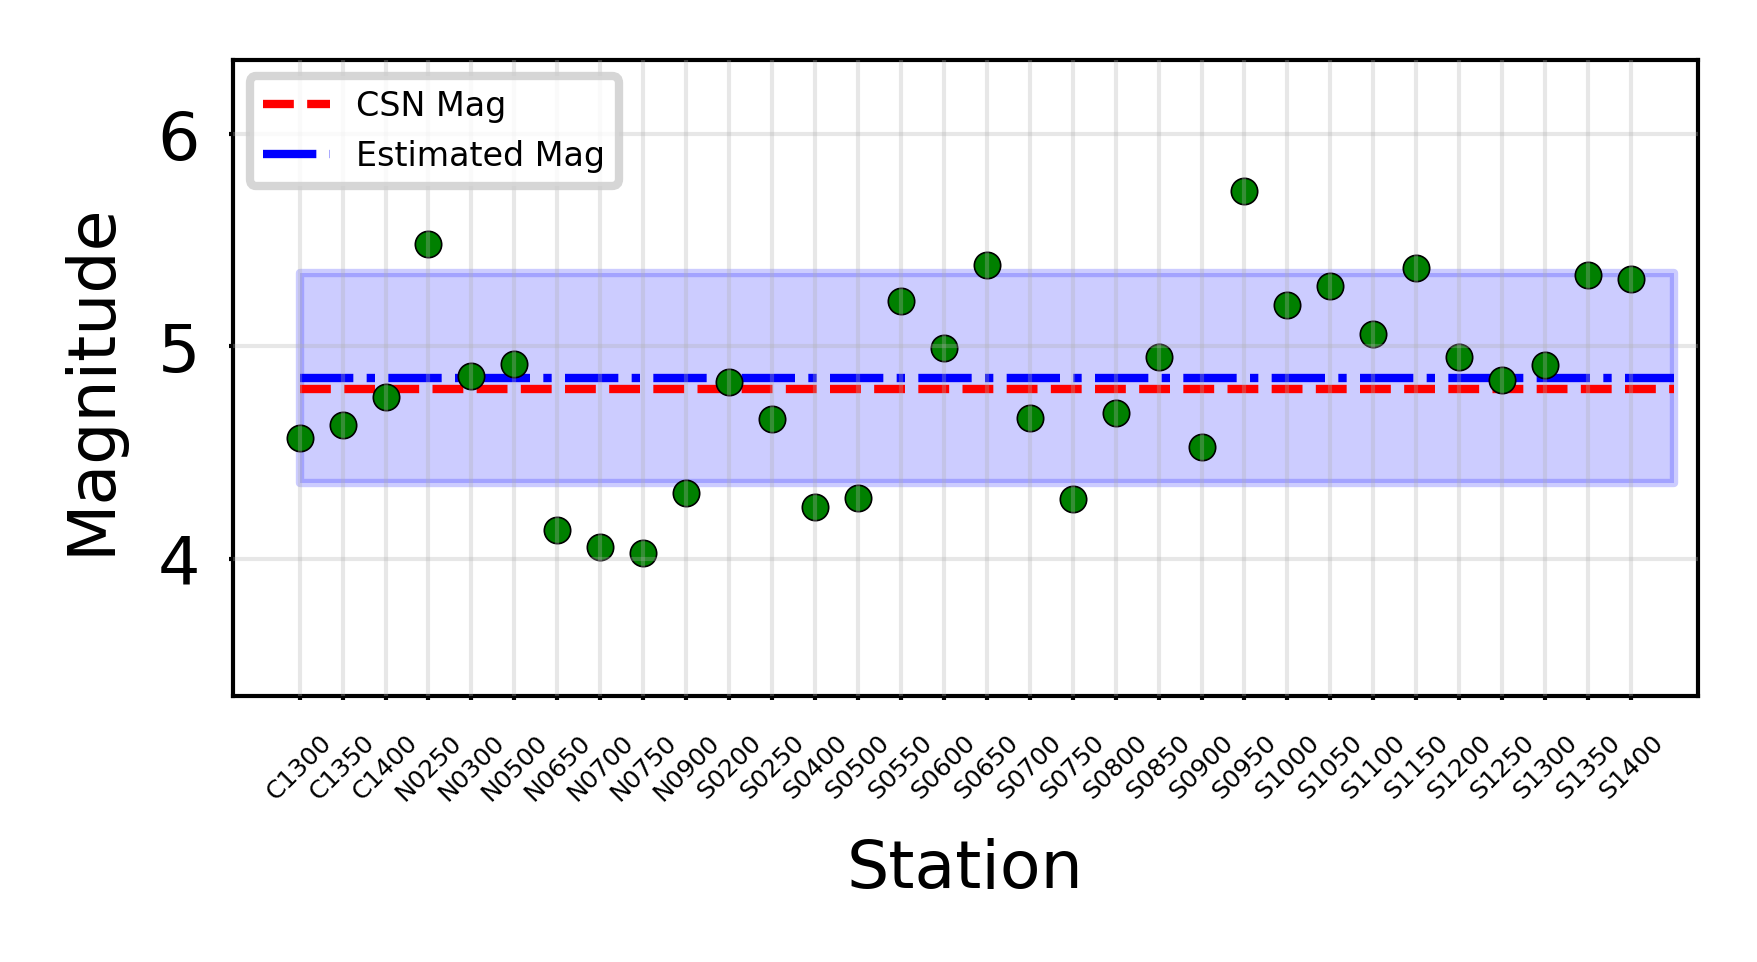

In [4]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=1, 
    figsize=(80*mm, 35*mm)
    )
ax = axes
ax.fill_between([0, len(magnitude_df)], median_mag-eror_mag, median_mag+eror_mag, color="b", alpha=0.2,zorder=0)
ax.hlines(true_mag, 0, len(magnitude_df), colors="r", linestyles="--", label="CSN Mag", zorder=1)
ax.hlines(median_mag, 0, len(magnitude_df), colors="b", linestyles="-.", label="Estimated Mag", zorder=1)
ax.scatter(magnitude_df["station"], magnitude_df["magnitude"], s=10, color="g", zorder=2, lw=0.2, edgecolor="k")
ax.set_ylim(median_mag-1.5, median_mag+1.5)
ax.set_xlabel("Station")
ax.set_ylabel("Magnitude")
ax.grid(True, alpha=0.3, zorder=0)
ax.tick_params(axis='x', rotation=45, labelsize=3)
ax.legend(loc="upper left", fontsize=4)

# Map with magnitudes

Map materials

In [5]:
ccnn_coords = pd.read_csv("../coords/CCN_N_coords.csv")
sern_coords = pd.read_csv("../coords/SER_N_coords.csv")
sers_coords = pd.read_csv("../coords/SER_S_coords.csv")
cables_coords = pd.concat([ccnn_coords, sern_coords, sers_coords], ignore_index=True)
F1_lat = magnitude_df["latitude"].values
F1_lon = magnitude_df["longitude"].values

ev_lon = event_info["longitude"]
ev_lat = event_info["latitude"]
ev_dep = event_info["depth"]
ev_mag = event_info["mag"]

santiago = [-33.4733, -70.6503]
concon = [-32.9597, -71.5155]
laserena = [-29.9448, -71.2546]
antofogasta = [-23.6513, -70.3910]
copiapò = [-27.3787, -70.0104]
iquique = [-20.2077, -69.9005]

study_area = [round(catalog["longitude"].min()) - 1, round(catalog["longitude"].max()) + 1, 
              round(catalog["latitude"].min()) - 0.5, round(catalog["latitude"].max() + 0.5)]

dataset = xr.open_dataset("../coords/topo.grd")
santiago_dict = dict(latitude=-33.4733, longitude=-70.6503)
concon_dict = dict(latitude=-32.9597, longitude=-71.5155)
laserena_dict = dict(latitude=-29.9448, longitude=-71.2546)

chile_large = xr.open_dataset("../coords/chile_large.grd")

data = dataset["z"].data
data = data.reshape(dataset["dimension"].values, order="F")[:, ::-1]
lon = np.arange(
    dataset["x_range"][0],
    dataset["x_range"][1] + dataset["spacing"][0] / 2,
    dataset["spacing"][0],
)
lat = np.arange(
    dataset["y_range"][0],
    dataset["y_range"][1] + dataset["spacing"][1] / 2,
    dataset["spacing"][1],
)
topo = xr.DataArray(data, {"longitude": lon, "latitude": lat})

chile_large = xr.open_dataset("../coords/chile_large.grd")
data = chile_large["z"].data
data = data.reshape(chile_large["dimension"].values, order="F")[:, ::-1]
lon_map = np.arange(
    chile_large["x_range"][0],
    chile_large["x_range"][1] + chile_large["spacing"][0] / 2,
    chile_large["spacing"][0],
)
lat_map = np.arange(
    chile_large["y_range"][0],
    chile_large["y_range"][1] + chile_large["spacing"][1] / 2,
    chile_large["spacing"][1],
)
topo_chile = xr.DataArray(data, {"longitude": lon_map, "latitude": lat_map})

# Colormaps
continuous_cmap = plt.cm.gnuplot_r
n_levels = 10
colors = continuous_cmap(np.linspace(0, 1, n_levels))
discrete_cmap = LinearSegmentedColormap.from_list("discrete", colors[:-1], N=n_levels)

continuous_cmap2 = plt.cm.gnuplot
n_levels = 20
colors = continuous_cmap2(np.linspace(0, 1, n_levels))
discrete_cmap2 = LinearSegmentedColormap.from_list("discrete", colors, N=n_levels)


(-34.0, -27.5)

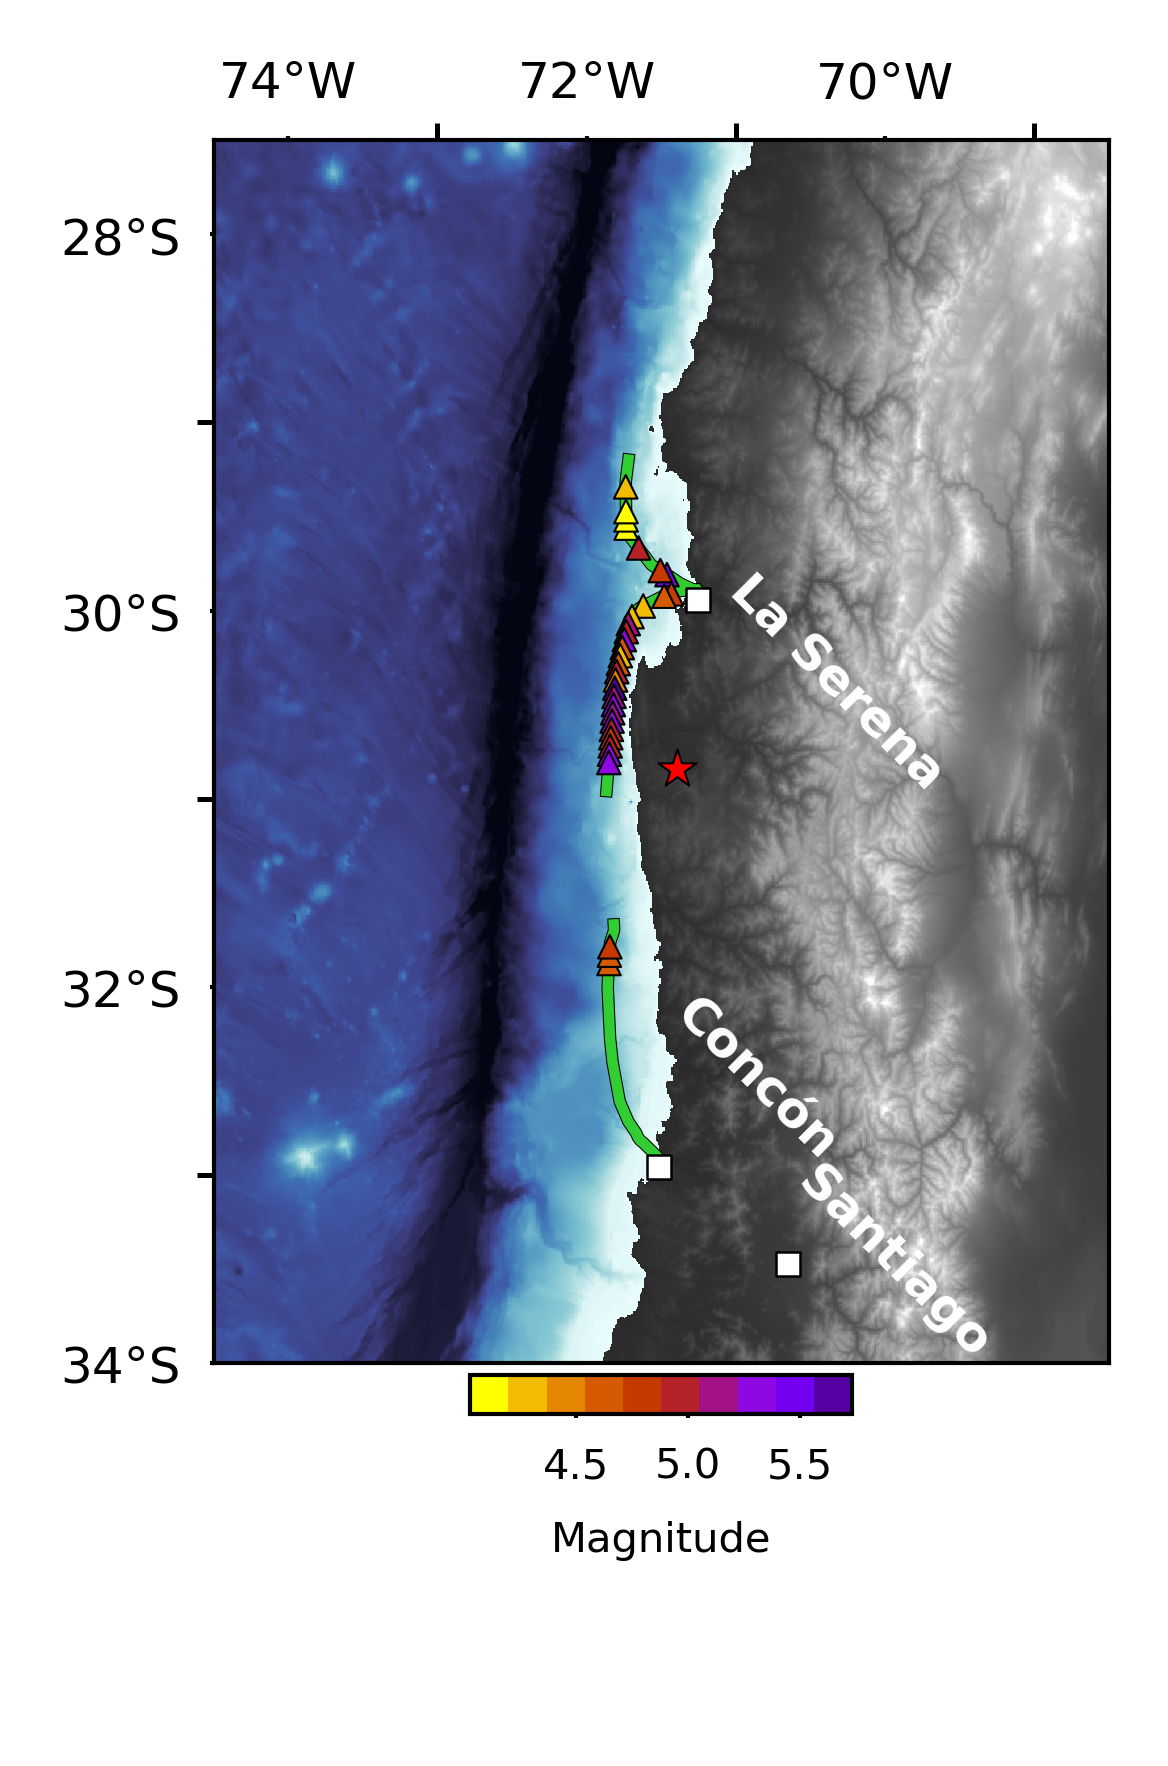

In [6]:
from matplotlib.offsetbox import AnchoredOffsetbox, AuxTransformBox
import numpy as np

fig, axes = plt.subplots(
    nrows=1, ncols=1, figsize=(50 * mm, 70 * mm), constrained_layout=False
)
ax = axes
colors_undersea = cmocean.cm.ice(np.linspace(0, 1, 256))
colors_land = cmocean.cm.gray(np.linspace(0.2, 1, 256))
all_colors = np.vstack((colors_undersea, colors_land))
terrain_map = mcolors.LinearSegmentedColormap.from_list(
    "terrain_map", 
    all_colors
    )
divnorm = mcolors.TwoSlopeNorm(vmin=-6.0, vcenter=0, vmax=6.0)
(topo_chile / 1000).T.plot.imshow(
ax=ax,
cmap=terrain_map,
norm=divnorm,
add_labels=False,
add_colorbar=False
)
ax.plot(ccnn_coords["longitude"], ccnn_coords["latitude"], color="k", lw=1.5, zorder=10)
ax.plot(sern_coords["longitude"], sern_coords["latitude"], color="k", lw=1.5, zorder=10)
ax.plot(sers_coords["longitude"], sers_coords["latitude"], color="k", lw=1.5, zorder=10)
ax.plot(ccnn_coords["longitude"], ccnn_coords["latitude"], color="limegreen", lw=1.25, zorder=10)
ax.plot(sern_coords["longitude"], sern_coords["latitude"], color="limegreen", lw=1.25, zorder=10)
ax.plot(sers_coords["longitude"], sers_coords["latitude"], color="limegreen", lw=1.25, zorder=10)
scf1 = ax.scatter(
    F1_lon, F1_lat,
    s=8,
    marker="^",
    c=magnitude_df["magnitude"].values,
    cmap=discrete_cmap,
    edgecolor="k",
    lw=0.25,
    zorder=100
)
cbar_ev = fig.colorbar(
    scf1,
    ax=ax,
    orientation="horizontal",
    pad=0.01,
    fraction=0.03,
    aspect=10
)
sc = ax.scatter(
    ev_lon, ev_lat,
    s=ev_mag ** 2,
    marker="*",
    c="r",
    edgecolor="k",
    lw=0.25,
    zorder=100
)

cbar_ev.set_label("Magnitude", fontsize=5)
cbar_ev.ax.tick_params(labelsize=5)
cbar_ev.outline.set_linewidth(0.5)

ax.scatter(
santiago_dict["longitude"], santiago_dict["latitude"], s=8, marker="s", fc="w", ec="k", lw=0.3, zorder=50
)
ax.scatter(
concon_dict["longitude"], concon_dict["latitude"], s=8, marker="s", fc="w", ec="k", lw=0.3, zorder=50
)
ax.scatter(
laserena_dict["longitude"], laserena_dict["latitude"], s=8, marker="s", fc="w", ec="k", lw=0.3, zorder=50
)
ax.text(
    santiago_dict["longitude"], santiago_dict["latitude"] - 0.5, "Santiago", fontsize=6,
    color="w", rotation=-45, weight="bold"
    )
ax.text(
    concon_dict["longitude"] + 0.05, concon_dict["latitude"] + 0.05, "Concón", fontsize=6,
    color="w", rotation=-45, weight="bold"
)
ax.text(
    laserena_dict["longitude"] + 0.15, laserena_dict["latitude"] - 1, "La Serena", fontsize=6,
    color="w", rotation=-45, weight="bold"
)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")
ax.yaxis.tick_left()
ax.tick_params(axis="both", labelsize=6)
ax.xaxis.set_major_locator(mticker.MultipleLocator(2.0))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1.0))
ax.yaxis.set_major_formatter(lambda x, pos: f"{abs(x):.0f}°S")
ax.yaxis.set_major_locator(mticker.MultipleLocator(2.0))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(1.0))
ax.xaxis.set_major_formatter(lambda x, pos: f"{abs(x):.0f}°W")
labels = ax.get_xticklabels() + ax.get_yticklabels()
[label.set_color("k") for label in labels]

scale_length_km = 100
scale_lat = -35.5
scale_lon_start = -75.0
deg_per_km = 1.0 / (111.32 * np.cos(np.deg2rad(abs(scale_lat))))
scale_lon_end = scale_lon_start + scale_length_km * deg_per_km
scale_bar_x = [scale_lon_start, scale_lon_end]
scale_bar_y = [scale_lat, scale_lat]
ax.plot(
    scale_bar_x, scale_bar_y,
    color="white", lw=1.25, solid_capstyle="butt", zorder=101
)
cap_width = 0.1
ax.plot([scale_bar_x[0], scale_bar_x[0]], [scale_bar_y[0] - cap_width, scale_bar_y[0] + cap_width], color="white", lw=1, zorder=102)
ax.plot([scale_bar_x[1], scale_bar_x[1]], [scale_bar_y[1] - cap_width, scale_bar_y[1] + cap_width], color="white", lw=1, zorder=102)
ax.text(
    np.mean(scale_bar_x), scale_lat - 0.15,
    f"{scale_length_km} km",
    ha="center", va="top", fontsize=4, color="white", weight="bold", zorder=103
)
lat_min, lat_max = -34, -27.5
lon_min, lon_max = -74.5, -68.5
lat_min, lat_max = -34, -27.5
lon_min, lon_max = -74.5, -68.5
lat0 = 0.5 * (lat_min + lat_max)
aspect = (lat_max - lat_min) / ((lon_max - lon_min) * np.cos(np.radians(lat0)))
ax.set_aspect(aspect)
ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

# Mag vs coords

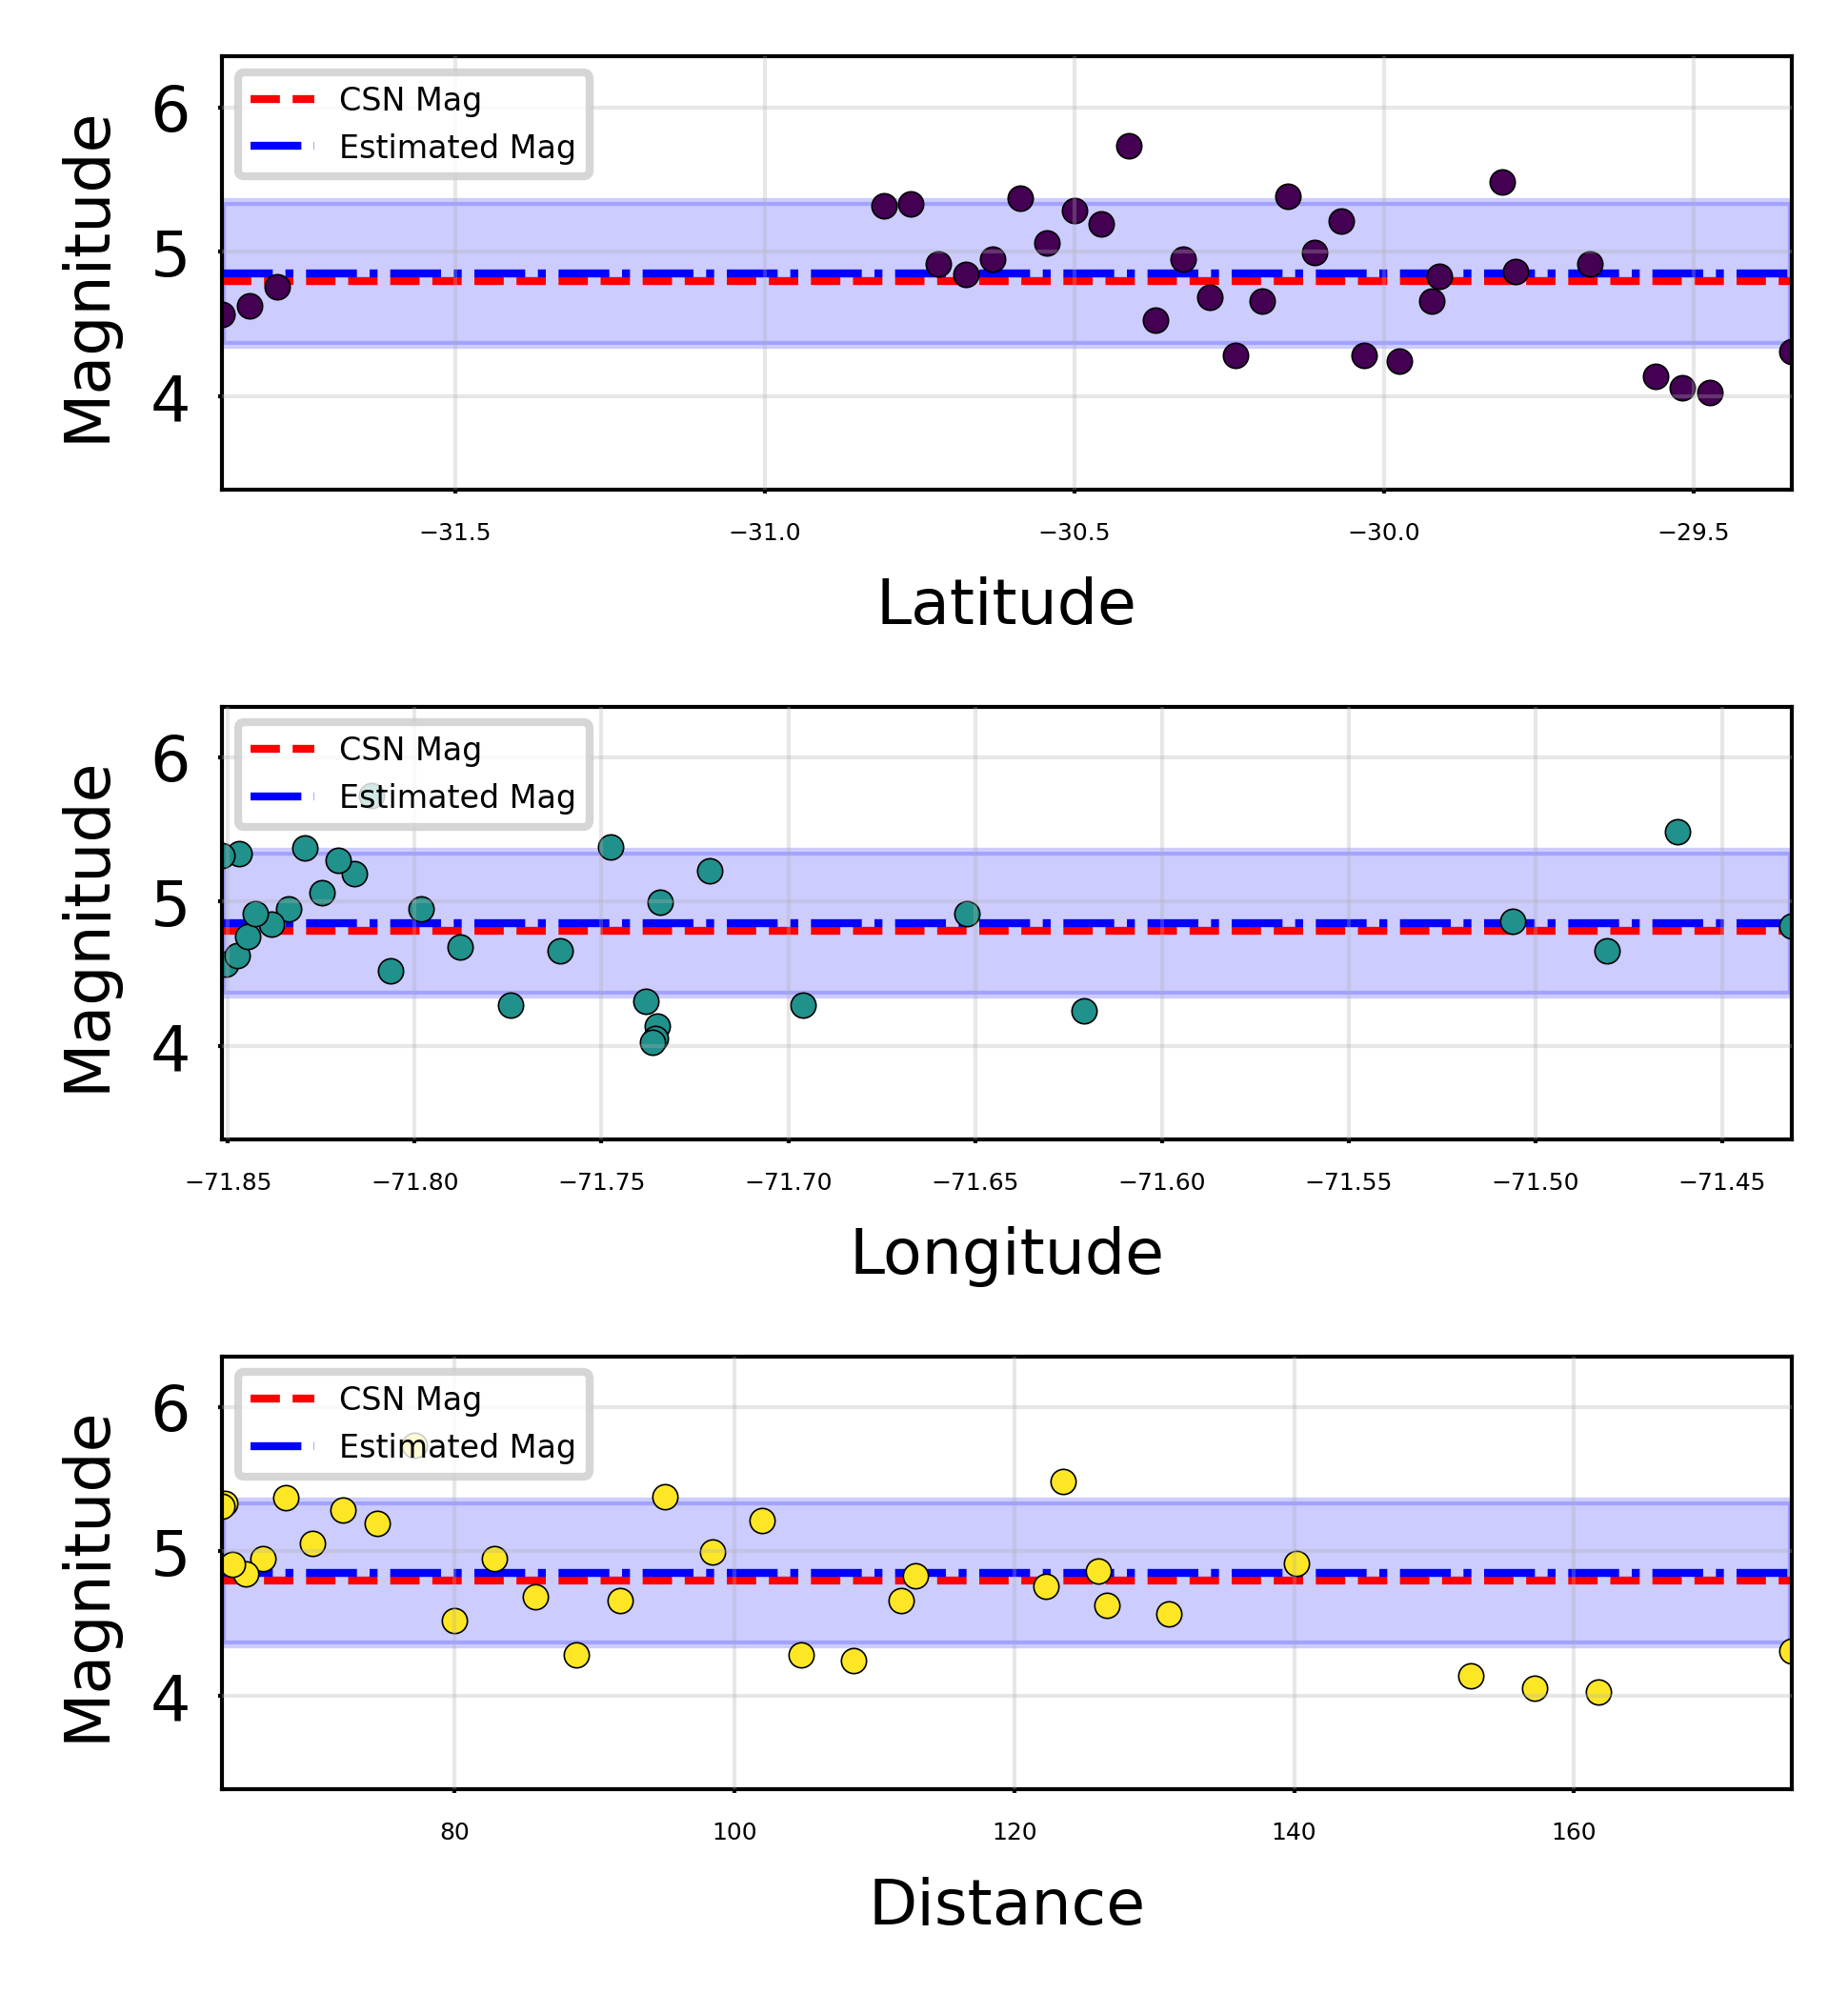

In [10]:
colors = plt.cm.viridis(np.linspace(0, 1, 3))
fig, axes = plt.subplots(
    nrows=3, 
    ncols=1, 
    figsize=(90*mm, 100*mm)
    )
fig.subplots_adjust(hspace=0.5)
for ix, coord in enumerate(["latitude", "longitude", "distance"]):
    ax = axes[ix]
    x = magnitude_df[coord]
    y = magnitude_df["magnitude"]
    ax.fill_between([x.min(), x.max()], median_mag-eror_mag, median_mag+eror_mag, color="b", alpha=0.2,zorder=0)
    ax.hlines(true_mag, x.min(), x.max(), colors="r", linestyles="--", label="CSN Mag", zorder=1)
    ax.hlines(median_mag, x.min(), x.max(), colors="b", linestyles="-.", label="Estimated Mag", zorder=1)
    ax.scatter(x, y, s=10, color=colors[ix], zorder=2, lw=0.2, edgecolor="k")
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(median_mag-1.5, median_mag+1.5)
    ax.set_xlabel(coord.capitalize())
    ax.set_ylabel("Magnitude")
    ax.grid(True, alpha=0.3, zorder=0)
    ax.tick_params(axis='x', rotation=0, labelsize=3)
    ax.legend(loc="upper left", fontsize=4)

